[Last year](/posts/ooms_plume_model/) I wrote up a short post on the original Ooms plume dispersion model[@ooms-1972] for calculating the trajectory and concentration profiles from vents, like typical stack gases, which are of a similar molar weight to air. I mentioned in passing that the original version of DEGADIS[@havens-1988] and other dense gas dispersion models use a later version of the Ooms dispersion model but did not go further with it at that time. This post is a short addendum implementing the later version of the Ooms plume dispersion model which accomodates dense gases[@ooms-1974].

## The Ooms Plume Dispersion Model - A Re-Cap

The Ooms plume dispersion model is one of the original integral plume dispersion models and comes from taking mass, energy, and momentum balances on a plume of gas -- integrating over a radial slice of the plume (hence *integral* plume model). To complete the integration some model of the concentration and momentum distribution within the plume is needed and the Ooms plume model assumes it is Gaussian.

::: {#fig-plume-sketch}
![](/posts/ooms_plume_model/plume_sketch.png)

A sketch of the plume and the coordinate system.
:::

The result is a system of differential algebraic equations with seven state variables, which is solved numerically to recover the trajectory of the plume and the centerline conditions. The density, concentration, etc. within the plume is then recovered using the centerline conditions and the assumed gaussian distribution.

The original model from 1972 was intended to model plumes of stack gases coming from combustion sources, and so made some simplifying assumptions in the plume energy balance. In particular it assumes the plume and the surrounding air are ideal gases with an identical molecular weight and specific heat capacity. Any buoyancy in the plume is thus only a consequence of temperature differences.

The 1974 update to the model changes the energy balance to allow for gases with different molecular weights and specific heat capacities, though at the expense of making the model equations more complicated.

### An Example Set-Up
To start with, let's suppose a release from an elevated stack into a standard dry air, with a windspeed of 2m/s and neglecting the density gradient

In [1]:
#| echo: false
using CairoMakie, Latexify

In [2]:
#| output: false
# some standard constants
const g    = 9.80665   # standard gravity, m/s²
const ρₐ₀  = 1.2250    # standard density dry air, kg/m³
const ΔρₐΔz= 0.0       # density gradient, Pa/m 
const MWₐ  = 0.0289652 # molar weight dry air, kg/mol
const cpₐ  = 1.006     # specific heat dry air, kJ/kg/K
const uₐ₀  = 2.0       # windspeed, m/s

2.0

Suppose the vent is 20cm in diameter, is 2m above the ground, and is releasing essentially hot air at 2m/s -- at whatever temperature would given the jet half the density of ambient air

In [3]:
#| output: false
# constants of the particular example
const D  = 0.2  # vent diameter, m
const h  = 2.0  # release height, m
const θ₀ = π/2  # release angle
const u₀ = uₐ₀  # release velocity, m/s
const MWⱼ= MWₐ  # molar weight, kg/kmol
const cpⱼ= cpₐ  # specific heat, kJ/kg/K
const ρⱼ = ρₐ₀/2# density, kg/m³
const c₀ = ρⱼ   # initial concentration, kg/m³

0.6125

This gives a set of model parameters that we can use to derive the *dimensionless* model parameters of the Ooms DAE.

### Model Constants

The [standard model constants](/posts/ooms_plume_model/#a-series-of-tedious-integrals) for the Ooms model are as follows, starting with the entrainment constants and drag coefficient used to model air entrainment.

::: {.callout-tip}
## ModelingToolkit

The majority of what follows is being done using [ModelingToolkit](https://docs.sciml.ai/ModelingToolkit/stable/), which greatly simplifies the building of DAEs like the Ooms plume dispersion model.
:::

In [4]:
#| echo: true
using ModelingToolkit, Symbolics, OrdinaryDiffEq
using ModelingToolkit: t_nounits as s, D_nounits as ∂

In [5]:
#| output: false
@constants begin 
    α₁ = 0.057 # entrainment constants
    α₂ = 0.5 
    α₃ = 1.0
    Cd = 0.3   # drag coefficient for the plume
end

4-element Vector{Num}:
 α₁
 α₂
 α₃
 Cd

The model has several additional constants that are a result of integrating over gaussian plume profiles, and are a function of the [turbulent Schmidt number](https://en.wikipedia.org/wiki/Schmidt_number#Turbulent_Schmidt_Number).

In [6]:
#| output: false
const λ² = 1.35 # the inverse of the turbulent Schmidt number

@constants begin
    C₁ = 1-exp(-2)
    C₂ = λ²*(1-exp(-2/λ²))
    C₃ = (λ²/(λ²+1))*(1-exp(-2*(λ²+1)/λ²))
    C₄ = (1-exp(-4))/4
    C₅ = (λ²/(4λ²+2))*(1-exp(-(4λ²+2)/λ²))
end

5-element Vector{Num}:
 C₁
 C₂
 C₃
 C₄
 C₅

### State Variables

The [system variables](/posts/ooms_plume_model/#dimensionless-form) are dimensionless versions of the concentration, $c$, width parameter, $b$, velocity, $u$, centerline angle, $\theta$, density, $\rho$, and coordinates of the plume centerline $x$ and $z$. The model is given with respect to *plume* coordinates $\theta$ and $s$ (see @fig-plume-sketch). These are given below with initial conditions.

In [7]:
#| output: false
@variables begin
    c(s) = 1.0
    b(s) = 1/(2√(2))
    u(s) = u₀/uₐ₀
    θ(s) = θ₀
    ρ(s) = (ρⱼ - ρₐ₀)/ρₐ₀
    x(s) = 0.0
    z(s) = h/D 
end

7-element Vector{Num}:
 c(t)
 b(t)
 u(t)
 θ(t)
 ρ(t)
 x(t)
 z(t)

### Conservation Relations

The model equations are generated from a series of [conservation relations](/posts/ooms_plume_model/#conservation-of) which are tedious to generate by hand but fairly straight forward for ModelingToolkit to produce (for a more detailed derivation see the [original post on the Ooms model](/posts/ooms_plume_model/))

#### Conservation of Mass

In [8]:
# conservation of mass
∫ρurdr = b^2*( (C₁ + C₃*ρ)*u + (2 + C₂*ρ)*cos(θ) )

# u′ = ∛(ϵ*b*D)/uₐ₀
u′ = 0.0

E = α₁*abs(u) + α₂*abs(sin(θ))*cos(θ) + α₃*u′

eqn1 = expand_derivatives( ∂( ∫ρurdr ) ) ~ 2*b*E

2((2 + C₂*ρ(t))*cos(θ(t)) + (C₁ + C₃*ρ(t))*u(t))*b(t)*Differential(t, 1)(b(t)) + (C₂*Differential(t, 1)(ρ(t))*cos(θ(t)) + (C₁ + C₃*ρ(t))*Differential(t, 1)(u(t)) + C₃*Differential(t, 1)(ρ(t))*u(t) - (2 + C₂*ρ(t))*sin(θ(t))*Differential(t, 1)(θ(t)))*(b(t)^2) ~ 2(abs(u(t))*α₁ + abs(sin(θ(t)))*cos(θ(t))*α₂)*b(t)

#### Conservation of Species

In [9]:
# conservation of species
∫curdr = c*b^2*(C₂*cos(θ) + C₃*u)

eqn2 = expand_derivatives( ∂( ∫curdr ) ) ~ 0

2(C₂*cos(θ(t)) + C₃*u(t))*c(t)*b(t)*Differential(t, 1)(b(t)) + (C₂*cos(θ(t)) + C₃*u(t))*(b(t)^2)*Differential(t, 1)(c(t)) + (C₃*Differential(t, 1)(u(t)) - C₂*sin(θ(t))*Differential(t, 1)(θ(t)))*c(t)*(b(t)^2) ~ 0

#### Conservation of Momentum - x direction

In [10]:
# conservation of momentum
# x-direction
∫ρu²cosθrdr = b^2*cos(θ)*(2u*cos(θ)*(C₁ + C₃*ρ) + 2u^2*(C₄ + C₅*ρ) 
                          + cos(θ)^2*(2 + C₂*ρ))

eqn3 = expand_derivatives( ∂( ∫ρu²cosθrdr ) ) ~ 
         b*( 2E + Cd*abs(sin(θ)^3) )

2((2 + C₂*ρ(t))*(cos(θ(t))^2) + 2(C₁ + C₃*ρ(t))*cos(θ(t))*u(t) + 2(C₄ + C₅*ρ(t))*(u(t)^2))*b(t)*cos(θ(t))*Differential(t, 1)(b(t)) - ((2 + C₂*ρ(t))*(cos(θ(t))^2) + 2(C₁ + C₃*ρ(t))*cos(θ(t))*u(t) + 2(C₄ + C₅*ρ(t))*(u(t)^2))*sin(θ(t))*(b(t)^2)*Differential(t, 1)(θ(t)) + (C₂*Differential(t, 1)(ρ(t))*(cos(θ(t))^2) + 2(C₁ + C₃*ρ(t))*Differential(t, 1)(u(t))*cos(θ(t)) + 2C₃*Differential(t, 1)(ρ(t))*cos(θ(t))*u(t) + 4(C₄ + C₅*ρ(t))*Differential(t, 1)(u(t))*u(t) + 2C₅*Differential(t, 1)(ρ(t))*(u(t)^2) - 2(2 + C₂*ρ(t))*sin(θ(t))*cos(θ(t))*Differential(t, 1)(θ(t)) - 2(C₁ + C₃*ρ(t))*sin(θ(t))*Differential(t, 1)(θ(t))*u(t))*(b(t)^2)*cos(θ(t)) ~ (Cd*abs(sin(θ(t))^3) + 2(abs(u(t))*α₁ + abs(sin(θ(t)))*cos(θ(t))*α₂))*b(t)

#### Conservation of Momentum - z direction

In [11]:
# z-direction
∫ρu²sinθrdr = b^2*sin(θ)*(2u*cos(θ)*(C₁ + C₃*ρ) + 2u^2*(C₄ + C₅*ρ) 
                          + cos(θ)^2*(2 + C₂*ρ))

@parameters g_bar = (g*D/uₐ₀^2)

eqn4 = expand_derivatives( ∂( ∫ρu²sinθrdr ) ) ~ 
	     -C₂*b^2*ρ*g_bar + sign(θ)*Cd*b*sin(θ)^2*cos(θ)

2((2 + C₂*ρ(t))*(cos(θ(t))^2) + 2(C₁ + C₃*ρ(t))*cos(θ(t))*u(t) + 2(C₄ + C₅*ρ(t))*(u(t)^2))*sin(θ(t))*b(t)*Differential(t, 1)(b(t)) + (C₂*Differential(t, 1)(ρ(t))*(cos(θ(t))^2) + 2(C₁ + C₃*ρ(t))*Differential(t, 1)(u(t))*cos(θ(t)) + 2C₃*Differential(t, 1)(ρ(t))*cos(θ(t))*u(t) + 4(C₄ + C₅*ρ(t))*Differential(t, 1)(u(t))*u(t) + 2C₅*Differential(t, 1)(ρ(t))*(u(t)^2) - 2(2 + C₂*ρ(t))*sin(θ(t))*cos(θ(t))*Differential(t, 1)(θ(t)) - 2(C₁ + C₃*ρ(t))*sin(θ(t))*Differential(t, 1)(θ(t))*u(t))*sin(θ(t))*(b(t)^2) + ((2 + C₂*ρ(t))*(cos(θ(t))^2) + 2(C₁ + C₃*ρ(t))*cos(θ(t))*u(t) + 2(C₄ + C₅*ρ(t))*(u(t)^2))*(b(t)^2)*cos(θ(t))*Differential(t, 1)(θ(t)) ~ -C₂*g_bar*(b(t)^2)*ρ(t) + Cd*(sin(θ(t))^2)*b(t)*sign(θ(t))*cos(θ(t))

#### Conservation of Energy

The [original energy balance](/posts/ooms_plume_model/#energy) from the 1972 paper followed from assuming that the molar weight and heat capacity of the jet were identical to the ambient air, allowing a lot of the integral to be cancelled out and simplified.

In this case we are considering an atmosphere where the density does not change appreciably with height over the domain of interest. This is an important point to highlight when using ModelingToolkit as the Ooms model generally assumes air density changes with height, but assumes it is a constant for the purposes of calculating derivatives. If an air density with an actual density gradient is plugged in here, ModelingToolkit will produce a different model than the Ooms model since it will apply the chain rule to $\rho_a$.

In [12]:
#| output: false
@parameters ρₐ = 1

1-element Vector{Num}:
 ρₐ

In [13]:
# original energy balance
∫ρucₚΔTrdr = b^2*(2cos(θ) + C₁*u - ρₐ*( u*(C₁ + C₃*ρ) 
                  + cos(θ)*(2 + C₂*ρ) ))

eqn5_1972 = expand_derivatives( ∂( ∫ρucₚΔTrdr ) ) ~ 2*b*(1 - ρₐ)*E

2(2cos(θ(t)) + C₁*u(t) - ((2 + C₂*ρ(t))*cos(θ(t)) + (C₁ + C₃*ρ(t))*u(t))*ρₐ)*b(t)*Differential(t, 1)(b(t)) + (C₁*Differential(t, 1)(u(t)) - 2sin(θ(t))*Differential(t, 1)(θ(t)) - (C₂*Differential(t, 1)(ρ(t))*cos(θ(t)) + (C₁ + C₃*ρ(t))*Differential(t, 1)(u(t)) + C₃*Differential(t, 1)(ρ(t))*u(t) - (2 + C₂*ρ(t))*sin(θ(t))*Differential(t, 1)(θ(t)))*ρₐ)*(b(t)^2) ~ 2(abs(u(t))*α₁ + abs(sin(θ(t)))*cos(θ(t))*α₂)*b(t)*(1 - ρₐ)

## The Updated Energy Balance

Adapting the original Ooms plume dispersion model to accomodate dense gas dispersion only requires changing one of the seven model equations: the energy balance. The integral itself is not easily solvable, which is why the original model made the assumption that the (ideal) gas in the jet had approximately the same molar weight and heat capacity as the ambient air. For releases of stack gases from combustion equipment this is approximately true and radically simplifies the integral.

For dense gases this is not true, and so another approxmation is required to make the energy balance tractable. Starting with the thermal energy in a differential slice of the plume

$$ \frac{d}{ds} \int_0^{\sqrt{2}b} \rho u c_p \left( T - T_{a,0} \right) r dr = b \rho_a E c_{p,a} \left( T_a - T_{a,0} \right) $$

Assuming both the vent gas and ambient air follow the ideal gas law, we can make the following substitutions:

$$ T = { {MW P } \over {R \rho} } $$

$$ T_a = { {MW_a P } \over {R \rho_a} } $$

$$ \frac{d}{ds} \int_0^{\sqrt{2}b} {{MW c_p} \over {MW_a c_{p,a}}} u \left( 1 - \frac{\rho}{\rho_{a,0}} \frac{MW_a}{MW} \right) r dr = b E \left( 1 - \frac{\rho_a}{\rho_{a,0}} \right) $$

The molar weight, $MW$, and heat capacity, $c_p$ can be recovered from the concentration and temperature in the plume

$$ MW = MW_j \frac{cT}{c_0 T_0} + MW_a \left( 1 - \frac{cT}{c_0 T_0} \right) $$

$$ MW c_p = MW_j c_{p,j} \frac{cT}{c_0 T_0} + MW_a c_{p,a} \left( 1 - \frac{cT}{c_0 T_0} \right) $$

Here Ooms makes an additional simplifying assumption: That the ratio ${{MW c_p} \over {MW_a c_{p,a} }}$ is a constant and equal to

$$ G_2 = {{MW c_p} \over {MW_a c_{p,a} }} = \frac{1}{2} \left( 1 + {{MW_j c_{p,j}} \over {MW_a c_{p,a} }} \right) $$

Substituting all of this into the integral, and doing a fair amount of algebra gives

$$ \int_0^{\sqrt{2}b} { {MW c_{p}} \over {MW_a c_{p,a}}} u \left[ 1 - \frac{\rho}{\rho_{a,0}} \left( 1 + \frac{c}{c_0} \frac{\rho_0}{\rho} \left( \frac{MW_a}{MW_j} - 1 \right) \right) \right] r dr$$

$$ = \int_0^{\sqrt{2}b} G_2 u \left[ 1 - \frac{\rho}{\rho_{a,0}} \left( 1 + \frac{c}{c_0} \frac{\rho_0}{\rho} G_1 \right) \right] r dr$$

$$ = u_a b^2 \int_0^{\sqrt{2}} G_2 \bar{u} \left[ 1 - \bar{\rho_a} \bar{\rho} - G_1 \bar{c} \bar{\rho_0} \bar{\rho_a} \right] \bar{r} d\bar{r}$$

Completing the integration, assuming the [gaussian profiles](http://localhost:4667/posts/ooms_plume_model/#similarity-profiles) for the system variables, results in

$$ \frac{1}{2} u_a b^2 G_2 \left[ \cos \theta \left( 2 - 2\bar{\rho_a} - C_2 \bar{\rho_a} \bar{\rho} - C_2 G_1 \bar{c} \bar{\rho_0} \right) + \bar{u} \left( C_1 - C_1 \bar{\rho_a} - C_3 \bar{\rho_a} \bar{\rho} - C_3 G_1 \bar{c} \bar{\rho_0} \right)\right] $$

Recalling that the overbar means the variable is in [dimensionless form](/posts/ooms_plume_model/#dimensionless-form). The change in the total thermal energy along the length of the plume is due to entrainment, which gives the following differential equation

$$ \frac{d}{d\bar{s}} \left\{ \bar{b}^2 G_2 \left[ \cos \theta \left( 2 - 2\bar{\rho_a} - C_2 \bar{\rho_a} \bar{\rho} - C_2 G_1 \bar{c} \bar{\rho_0} \right) + \bar{u} \left( C_1 - C_1 \bar{\rho_a} - C_3 \bar{\rho_a} \bar{\rho} - C_3 G_1 \bar{c} \bar{\rho_0} \right)\right] \right\} = 2 \bar{b} \left( 1 - \bar{\rho_a} \right) \bar{E} $$

Since the entire equation is in dimensionless form, I drop the overbars from here on.

In [14]:
#| output: false
@parameters begin
    ρ₀ = ρⱼ/ρₐ₀
    G₁ = MWₐ/MWⱼ - 1
    G₂ = 0.5*(1 + (MWⱼ*cpⱼ)/(MWₐ*cpₐ))
end

3-element Vector{Num}:
 ρ₀
 G₁
 G₂

In [15]:
# updated energy balance
∫ρucₚΔTrdr = G₂*b^2*(
              cos(θ)*(2 - 2*ρₐ - C₂*ρₐ*ρ - C₂*G₁*c*ρ₀)
            + u*(C₁ - C₁*ρₐ - C₃*ρₐ*ρ - C₃*G₁*c*ρ₀) )

eqn5_1974 = expand_derivatives( ∂( ∫ρucₚΔTrdr ) ) ~ 2*b*(1 - ρₐ)*E

2((2 - 2ρₐ - C₂*ρ(t)*ρₐ - C₂*G₁*c(t)*ρ₀)*cos(θ(t)) + (C₁ - C₁*ρₐ - C₃*ρ(t)*ρₐ - C₃*G₁*c(t)*ρ₀)*u(t))*G₂*b(t)*Differential(t, 1)(b(t)) + ((-C₂*Differential(t, 1)(ρ(t))*ρₐ - C₂*G₁*Differential(t, 1)(c(t))*ρ₀)*cos(θ(t)) + (C₁ - C₁*ρₐ - C₃*ρ(t)*ρₐ - C₃*G₁*c(t)*ρ₀)*Differential(t, 1)(u(t)) + (-C₃*Differential(t, 1)(ρ(t))*ρₐ - C₃*G₁*Differential(t, 1)(c(t))*ρ₀)*u(t) - (2 - 2ρₐ - C₂*ρ(t)*ρₐ - C₂*G₁*c(t)*ρ₀)*sin(θ(t))*Differential(t, 1)(θ(t)))*G₂*(b(t)^2) ~ 2(abs(u(t))*α₁ + abs(sin(θ(t)))*cos(θ(t))*α₂)*b(t)*(1 - ρₐ)

## Building the Two Models

Having ModelingToolkit do all the work, it is easy to build the two models and solve them, starting with the original 1972 model

In [16]:
@named ooms1972 = ODESystem(
       [ eqn1
	     eqn2
	     eqn3
	     eqn4
	     eqn5_1972
	     ∂(x) ~ cos(θ)
	     ∂(z) ~ sin(θ) ], s)
model_ooms1972 = mtkcompile(ooms1972)

Model ooms1972:
Equations (12):
  12 standard: see equations(ooms1972)
Unknowns (12): see unknowns(ooms1972)
  b(t)
  ρ(t)
  u(t)
  θ(t)
  bˍt(t)
  ρˍt(t)
  ⋮
Parameters (10): see parameters(ooms1972)
  g_bar
  ρₐ
  C₄
  α₂
  Cd
  C₂
  ⋮

In [17]:
#| output: false
span = (0.0, 500.0)

(0.0, 500.0)

In [18]:
#| output: false
prob_ooms1972 = ODEProblem(model_ooms1972, [], span)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Initialization status: FULLY_DETERMINED
Non-trivial mass matrix: true
timespan: (0.0, 500.0)
u0: 12-element Vector{Float64}:
  0.35355339059327373
 -0.5
  1.0
  1.5707963267948966
  0.0
  0.0
  0.0
  0.0
  1.0
  0.0
 10.0
  0.0

In [19]:
sol_ooms1972 = solve(prob_ooms1972, Rodas5P())

sol_ooms1972.retcode

ReturnCode.Success = 1

Since the two models share almost everything, except the energy balance, creating the 1974 version of the Ooms plume dispersion model is very straightforward

In [20]:
@named ooms1974 = ODESystem(
       [ eqn1
	     eqn2
	     eqn3
	     eqn4
	     eqn5_1974
	     ∂(x) ~ cos(θ)
	     ∂(z) ~ sin(θ) ], s)
model_ooms1974 = mtkcompile(ooms1974)

Model ooms1974:
Equations (12):
  12 standard: see equations(ooms1974)
Unknowns (12): see unknowns(ooms1974)
  b(t)
  ρ(t)
  u(t)
  θ(t)
  c(t)
  bˍt(t)
  ⋮
Parameters (13): see parameters(ooms1974)
  g_bar
  G₂
  ρₐ
  G₁
  ρ₀
  C₄
  ⋮

In [21]:
#| output: false
prob_ooms1974 = ODEProblem(model_ooms1974, [], span)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Initialization status: FULLY_DETERMINED
Non-trivial mass matrix: true
timespan: (0.0, 500.0)
u0: 12-element Vector{Float64}:
  0.35355339059327373
 -0.5
  1.0
  1.5707963267948966
  1.0
  0.0
  0.0
  0.0
  0.0
  0.0
 10.0
  0.0

In [22]:
sol_ooms1974 = solve(prob_ooms1974, Rodas5P())

sol_ooms1974.retcode

ReturnCode.Success = 1

Comparing results we find that, for the same plume with the same initial conditions, we get the same results, @fig-model-compare. Which is a good start!

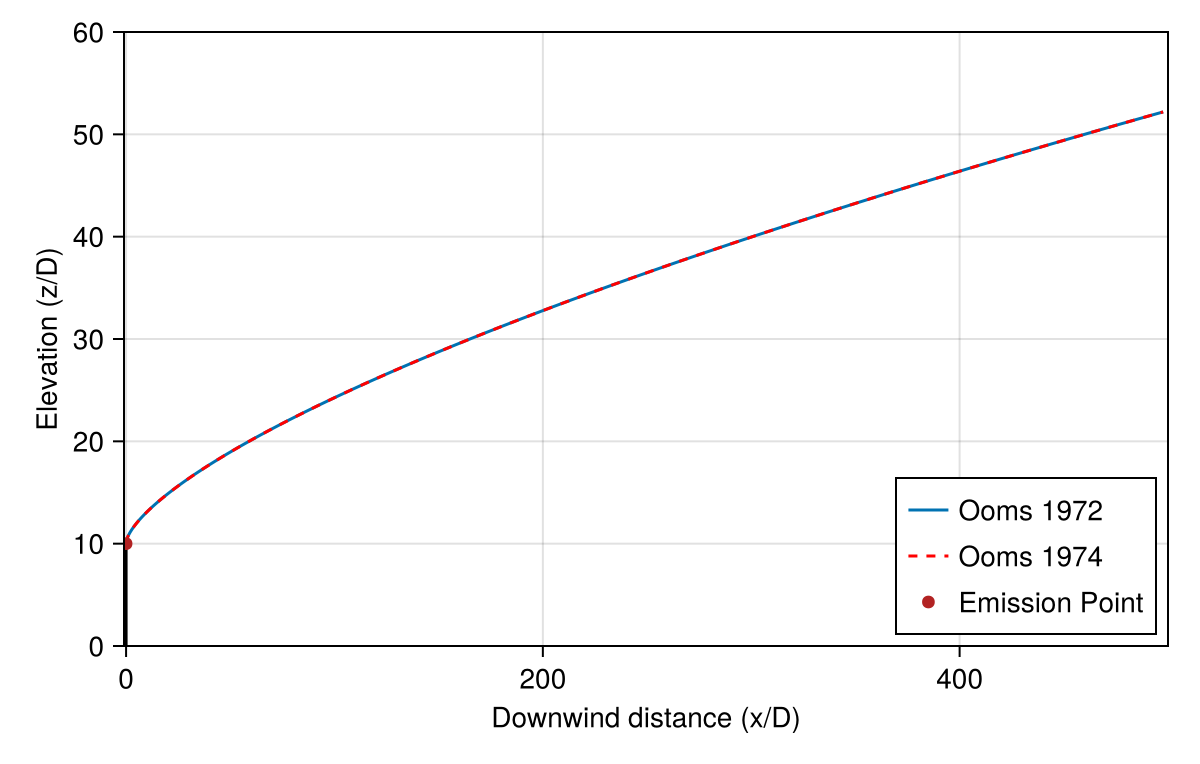

In [23]:
#| echo: false
#| label: fig-model-compare
#| fig-cap: "The plume height as a function of downwind distance, comparing the 1972 and 1974 versions of the Ooms plume dispersion model."
f1 = Figure(figurepadding=0)
ax1 = Axis(f1[1, 1],
    xlabel = "Downwind distance (x/D)",
    ylabel = "Elevation (z/D)",
    limits = ((-1,500),(0,60)),
    #aspect = DataAspect()
)
plot!(ax1, sol_ooms1972, idxs=(x,z), label="Ooms 1972")
plot!(ax1, sol_ooms1974, idxs=(x,z), color=:red, linestyle=:dash, label="Ooms 1974")
lines!(ax1, [0, 0], [0, h/D], color=:black, label=nothing)
scatter!(ax1, [0], [h/D], color=:firebrick, label="Emission Point")
axislegend(position=:rb)
rowsize!(f1.layout,1,Aspect(1, 30/51))
resize_to_layout!(f1)
f1
     


## Sources of Density Difference

We can go further and look at what changes if we model a gas with a significantly different molecular weight and specific heat capacity than air. For example, suppose we want to compare a jet of hot air to a jet of *helium* at ambient temperature, where we have adjusted the hot air jet temperature such that both have the same starting density.

In [24]:
#|output: false
const MW_He = 0.0040026 # molar weight helium, kg/mol
const cp_He = 5.191625  # specific heat helium, kJ/kg/K

hot_gas = [
    model_ooms1972.ρ => MW_He/MWₐ - 1
    ]

1-element Vector{Pair{Num, Float64}}:
 ρ(t) => -0.861813486528662

In [25]:
#| output: false
light_gas = [
    model_ooms1974.ρ  => MW_He/MWₐ - 1,
    model_ooms1974.ρ₀ => MW_He/MWₐ,
    model_ooms1974.G₁ => MWₐ/MW_He - 1,
    model_ooms1974.G₂ => 0.5*(1 + (MW_He*cp_He)/(MWₐ*cpₐ))
    ]

4-element Vector{Pair{Num, Float64}}:
 ρ(t) => -0.861813486528662
   ρ₀ => 0.13818651347133803
   G₁ => 6.236596212461899
   G₂ => 0.8565668777339142

We can update the model parameters and re-run both models easily enough

In [26]:
prob_ooms1972_He = ODEProblem(model_ooms1972, hot_gas, span)

sol_ooms1972_He = solve(prob_ooms1972_He, Rodas5P())

sol_ooms1972_He.retcode

ReturnCode.Success = 1

In [27]:
prob_ooms1974_He = ODEProblem(model_ooms1974, light_gas, span)

sol_ooms1974_He = solve(prob_ooms1974_He, Rodas5P())

sol_ooms1974_He.retcode

ReturnCode.Success = 1

The result, perhaps surprisingly, is the exact same plume, @fig-model-density. It seems like the updated Ooms model is not very sensitive to differences in specific heat capacity and molecular weight, at least for jets with the same initial density.

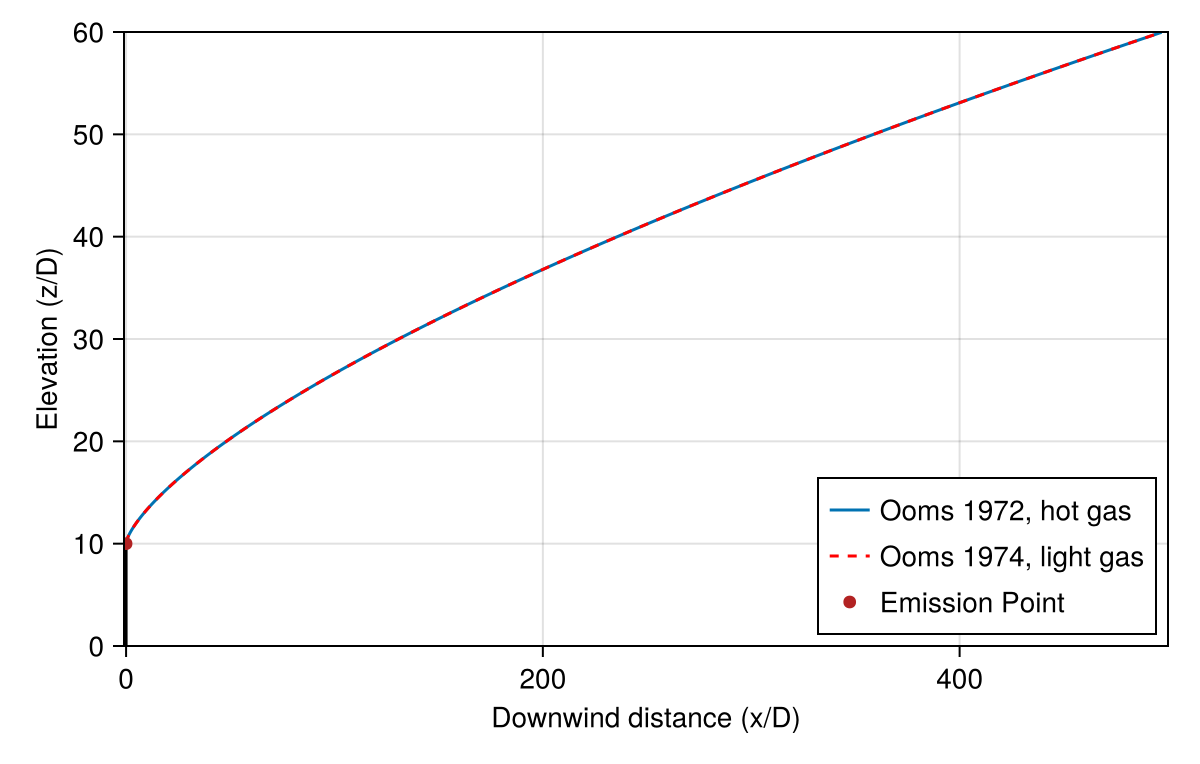

In [28]:
#| echo: false
#| label: fig-model-density
#| fig-cap: "The plume height as a function of downwind distance, comparing the 1972 and 1974 versions of the model with a helium jet."
f2 = Figure(figurepadding=0)
ax2 = Axis(f2[1, 1],
    xlabel = "Downwind distance (x/D)",
    ylabel = "Elevation (z/D)",
    limits = ((-1,500),(0,60)),
    #aspect = DataAspect()
)
plot!(ax2, sol_ooms1972_He, idxs=(x,z), label="Ooms 1972, hot gas")
plot!(ax2, sol_ooms1974_He, idxs=(x,z), color=:red, linestyle=:dash, label="Ooms 1974, light gas")
lines!(ax2, [0, 0], [0, h/D], color=:black, label=nothing)
scatter!(ax2, [0], [h/D], color=:firebrick, label="Emission Point")
axislegend(position=:rb)
rowsize!(f2.layout,1,Aspect(1, 30/51))
resize_to_layout!(f2)
f2
     


In fact, for models like this one where the air density does not change with height, the model is *entirely* insensitive to specific heat capacity. We can see this by re-examining the thermal energy balance for the case where $\rho_a = 1$

$$ \frac{d}{d\bar{s}} \left\{ \bar{b}^2 G_2 \left[ \cos \theta \left( 2 - 2\bar{\rho_a} - C_2 \bar{\rho_a} \bar{\rho} - C_2 G_1 \bar{c} \bar{\rho_o} \right) + \bar{u} \left( C_1 - C_1 \bar{\rho_a} - C_3 \bar{\rho_a} \bar{\rho} - C_3 G_1 \bar{c} \bar{\rho_0} \right)\right] \right\} = 2 \bar{b} \left( 1 - \bar{\rho_a} \right) \bar{E} $$

$$ -G_2 \frac{d}{d\bar{s}} \left\{ \bar{b}^2  \left( C_2 \cos \theta + C_3 \bar{u} \right) \left( \bar{\rho} + G_1 \bar{c} \bar{\rho_0} \right) \right\} = 0 $$

$$ \frac{d}{d\bar{s}} \left\{ \bar{b}^2  \left( C_2 \cos \theta + C_3 \bar{u} \right) \left( \bar{\rho} + G_1 \bar{c} \bar{\rho_0} \right) \right\} = 0 $$

Since we can eliminate $G_2$ entirely, and that is the only place where the specific heat appears in the model, the model is entirely insensitive to differences in specific heat capacity between the jet and the ambient air when there is no density gradient in the ambient air.

Comparing this to the 1972 Ooms model, when $\rho_a = 1$ we find, unsurprisingly, that they are quite similar

$$ \frac{d}{d\bar{s}} \left\{ \bar{b}^2  \bar{\rho} \left( C_2 \cos \theta + C_3 \bar{u} \right) \right\} = 0 $$

Just from playing around, the 1974 model also appears to be quite insensitive to differences in $G_1$, in that low density jets of gas appear to give the same plume regardless of how the density comes about -- from temperature or molecular weight. I haven't looked at it too closely but I wouldn't be surprised if the terms containing $G_1$ turn out to be mostly constant (i.e. the derivative goes to zero). It could just be a coincidence, but quite a surprising coincidence, that every example I've tried the value of $G_1$ hasn't mattered.

::: {.callout-note}
## Update

I did think of an easy way of showing that the model is also insensitive to $G_1$, for the case when $\bar{c} \propto \bar{\rho}$. Suppose $\bar{c} = k \bar{\rho}$ where *k* is some constant of proportionality (it doesn't matter what it is). Picking up where I left off with the 1974 version of the Ooms energy balance equation with $\bar{\rho}_a = 1$

$$ \frac{d}{d\bar{s}} \left\{ \bar{b}^2  \left( C_2 \cos \theta + C_3 \bar{u} \right) \left( \bar{\rho} + G_1 \bar{c} \bar{\rho_0} \right) \right\} = 0 $$

$$ \frac{d}{d\bar{s}} \left\{ \bar{b}^2  \left( C_2 \cos \theta + C_3 \bar{u} \right) \left( 1 + G_1 k \bar{\rho_0} \right) \bar{\rho} \right\} = 0 $$

Since $\left( 1 + G_1 k \bar{\rho_0} \right)$ is a constant we can pull it out of the derivative

$$ \left( 1 + G_1 k \bar{\rho_0} \right) \frac{d}{d\bar{s}} \left\{ \bar{b}^2  \bar{\rho} \left( C_2 \cos \theta + C_3 \bar{u} \right)  \right\} = 0 $$

and ultimately eliminate it entirely

$$ \frac{d}{d\bar{s}} \left\{ \bar{b}^2  \bar{\rho} \left( C_2 \cos \theta + C_3 \bar{u} \right)  \right\} = 0 $$

Which is the 1972 version of the thermal energy balance.

That $\bar{c} \propto \bar{\rho}$ isn't an onerous condition, in fact it follows directly from the ideal gas assumption and the mixing rule given in the definition of $MW$, in fact it is

$$ \bar{\rho} = { {\rho - \rho_a} \over \rho_a} = { {\rho_0 - \rho_{a,0}} \over \rho_{a,0}} \bar{c} $$

Which is a round-about way of saying that, with the assumptions underlying the 1974 model, when $\bar{\rho_a}=1$ the model reduces down to the 1972 model and the exact molar weight and specific heat capacity of the gas don't actually matter.
:::

The result of this is that, actually, the 1972 version of the Ooms plume dispersion model probably works fine in most situations being used for chemical engineering consequence analysis, where atmospheric density gradients are typically neglected. Once the right-hand-side of the equation is zero, a lot of complexity can be eliminated.

## Breaking Out the Result

While it is nice to have ModelingToolkit do all the algebra for us, I often want the model to be stand alone, i.e. not require ModelingToolkit to be part of the project dependencies. Mostly because it is a large library and starting a new project in julia can be tedious if there are lots of large libraries that need to be downloaded and compiled.

We can take the code generated by ModelingToolkit and break it out into a separate (in-place) system and mass matrix. These are presented below for ease of copying-and-pasting, starting with the original 1972 model:

In [29]:
#| output: false
function rhs_ooms1972!(dstate, state, params, s)
    c, b, u, θ, ρ, x, z, dc, db, du, dθ, dρ  = state
    α₁, α₂, α₃, Cd, C₁, C₂, C₃, C₄, C₅, g_bar, ρₒ, G₁, G₂, u_fn, ρₐ_fn = params
    u′ = u_fn(b)
    ρₐ = ρₐ_fn(z)
    E = u′*α₃ + abs(u)*α₁ + abs(sin(θ))*cos(θ)*α₂
    
    dstate[1] = dc
    dstate[2] = db
    dstate[3] = du
    dstate[4] = dθ
    dstate[5] = dρ
    dstate[6] = cos(θ)
    dstate[7] = sin(θ)
    
    # conservation of mass
    dstate[8] = 2E*b - 2((2 + C₂*ρ)*cos(θ) + (C₁ + C₃*ρ)*u)*db*b - (C₂*cos(θ)*dρ + C₃*dρ*u + (C₁ + C₃*ρ)*du - (2 + C₂*ρ)*dθ*sin(θ))*(b^2)

    # conservation of species
    dstate[9] = -2(C₂*cos(θ) + C₃*u)*db*c*b - (C₂*cos(θ) + C₃*u)*dc*(b^2) - (C₃*du - C₂*dθ*sin(θ))*c*(b^2)
    
    # conservation of momentum - x-direction
    dstate[10] = (Cd*abs(sin(θ)^3) + 2E)*b - 2((2 + C₂*ρ)*(cos(θ)^2) + 2(C₁ + C₃*ρ)*cos(θ)*u + 2(C₄ + C₅*ρ)*(u^2))*db*cos(θ)*b + ((2 + C₂*ρ)*(cos(θ)^2) + 2(C₁ + C₃*ρ)*cos(θ)*u + 2(C₄ + C₅*ρ)*(u^2))*dθ*sin(θ)*(b^2) - (C₂*(cos(θ)^2)*dρ + 2C₃*cos(θ)*dρ*u + 2(C₁ + C₃*ρ)*cos(θ)*du + 2C₅*dρ*(u^2) + 4(C₄ + C₅*ρ)*u*du - 2(2 + C₂*ρ)*dθ*cos(θ)*sin(θ) - 2(C₁ + C₃*ρ)*dθ*sin(θ)*u)*cos(θ)*(b^2)
    
    # conservation of momentum - z-direction
    dstate[11] = (-C₂*g_bar*ρ*(b^2)) + Cd*cos(θ)*(sin(θ)^2)*sign(θ)*b - 2((2 + C₂*ρ)*(cos(θ)^2) + 2(C₁ + C₃*ρ)*cos(θ)*u + 2(C₄ + C₅*ρ)*(u^2))*db*sin(θ)*b - ((2 + C₂*ρ)*(cos(θ)^2) + 2(C₁ + C₃*ρ)*cos(θ)*u + 2(C₄ + C₅*ρ)*(u^2))*dθ*cos(θ)*(b^2) - (C₂*(cos(θ)^2)*dρ + 2C₃*cos(θ)*dρ*u + 2(C₁ + C₃*ρ)*cos(θ)*du + 2C₅*dρ*(u^2) + 4(C₄ + C₅*ρ)*u*du - 2(2 + C₂*ρ)*dθ*cos(θ)*sin(θ) - 2(C₁ + C₃*ρ)*dθ*sin(θ)*u)*sin(θ)*(b^2)

    # conservation of energy
    dstate[12] = 2E*b*(1 - ρₐ) - 2(2cos(θ) + C₁*u - ((2 + C₂*ρ)*cos(θ) + (C₁ + C₃*ρ)*u)*ρₐ)*db*b - (C₁*du - 2dθ*sin(θ) - (C₂*cos(θ)*dρ + C₃*dρ*u + (C₁ + C₃*ρ)*du - (2 + C₂*ρ)*dθ*sin(θ))*ρₐ)*(b^2)
    
end

rhs_ooms1972! (generic function with 1 method)

the 1974 model:

In [30]:
#| output: false
function rhs_ooms1974!(dstate, state, params, s)
    c, b, u, θ, ρ, x, z, dc, db, du, dθ, dρ  = state
    α₁, α₂, α₃, Cd, C₁, C₂, C₃, C₄, C₅, g_bar, ρₒ, G₁, G₂, u_fn, ρₐ_fn = params
    u′ = u_fn(b)
    ρₐ = ρₐ_fn(z)
    E = abs(u)*α₁ + abs(sin(θ))*cos(θ)*α₂ + u′*α₃
    
    dstate[1] = dc
    dstate[2] = db
    dstate[3] = du
    dstate[4] = dθ
    dstate[5] = dρ
    dstate[6] = cos(θ)
    dstate[7] = sin(θ)
    
    # conservation of mass
    dstate[8] = 2E*b - 2((2 + C₂*ρ)*cos(θ) + (C₁ + C₃*ρ)*u)*db*b - (C₂*cos(θ)*dρ + C₃*dρ*u + (C₁ + C₃*ρ)*du - (2 + C₂*ρ)*dθ*sin(θ))*(b^2)

    # conservation of species
    dstate[9] = -2(C₂*cos(θ) + C₃*u)*db*c*b - (C₂*cos(θ) + C₃*u)*dc*(b^2) - (C₃*du - C₂*dθ*sin(θ))*c*(b^2)
    
    # conservation of momentum - x-direction
    dstate[10] = (Cd*abs(sin(θ)^3) + 2E)*b - 2((2 + C₂*ρ)*(cos(θ)^2) + 2(C₁ + C₃*ρ)*cos(θ)*u + 2(C₄ + C₅*ρ)*(u^2))*db*cos(θ)*b + ((2 + C₂*ρ)*(cos(θ)^2) + 2(C₁ + C₃*ρ)*cos(θ)*u + 2(C₄ + C₅*ρ)*(u^2))*dθ*sin(θ)*(b^2) - (C₂*(cos(θ)^2)*dρ + 2C₃*cos(θ)*dρ*u + 2(C₁ + C₃*ρ)*cos(θ)*du + 2C₅*dρ*(u^2) + 4(C₄ + C₅*ρ)*u*du - 2(2 + C₂*ρ)*dθ*cos(θ)*sin(θ) - 2(C₁ + C₃*ρ)*dθ*sin(θ)*u)*cos(θ)*(b^2)
    
    # conservation of momentum - z-direction
    dstate[11] = (-C₂*g_bar*ρ*(b^2)) + Cd*cos(θ)*(sin(θ)^2)*sign(θ)*b - 2((2 + C₂*ρ)*(cos(θ)^2) + 2(C₁ + C₃*ρ)*cos(θ)*u + 2(C₄ + C₅*ρ)*(u^2))*db*sin(θ)*b - ((2 + C₂*ρ)*(cos(θ)^2) + 2(C₁ + C₃*ρ)*cos(θ)*u + 2(C₄ + C₅*ρ)*(u^2))*dθ*cos(θ)*(b^2) - (C₂*(cos(θ)^2)*dρ + 2C₃*cos(θ)*dρ*u + 2(C₁ + C₃*ρ)*cos(θ)*du + 2C₅*dρ*(u^2) + 4(C₄ + C₅*ρ)*u*du - 2(2 + C₂*ρ)*dθ*cos(θ)*sin(θ) - 2(C₁ + C₃*ρ)*dθ*sin(θ)*u)*sin(θ)*(b^2)

    # conservation of energy
    dstate[12] = 2E*b*(1 - ρₐ) - 2((2 - 2ρₐ - C₂*ρ*ρₐ - C₂*G₁*c*ρₒ)*cos(θ) + (C₁ - C₁*ρₐ - C₃*ρ*ρₐ - C₃*G₁*c*ρₒ)*u)*G₂*db*b - ((-C₂*dρ*ρₐ - C₂*G₁*dc*ρₒ)*cos(θ) + (C₁ - C₁*ρₐ - C₃*ρ*ρₐ - C₃*G₁*c*ρₒ)*du + (-C₃*dρ*ρₐ - C₃*G₁*dc*ρₒ)*u - (2 - 2ρₐ - C₂*ρ*ρₐ - C₂*G₁*c*ρₒ)*sin(θ)*dθ)*G₂*(b^2)

    
end

rhs_ooms1974! (generic function with 1 method)

The mass matrix for these systems is just a diagonal matrix with the first 7 elements as 1 and the rest all zeros. The initial conditions for the first seven entries are simply those for the state variables, the differential variables are initialized to zero for now (more on that later).

In [31]:
#| output: false
using LinearAlgebra
M = Diagonal(vcat(ones(7),zeros(5)))

init = [1.0; 1/(2√(2)); u₀/uₐ₀; θ₀; (ρⱼ - ρₐ₀)/ρₐ₀; 0.0; h/D]
initial_vals=vcat(init,zeros(5))

12-element Vector{Float64}:
  1.0
  0.35355339059327373
  1.0
  1.5707963267948966
 -0.5
  0.0
 10.0
  0.0
  0.0
  0.0
  0.0
  0.0

In *this particular notebook* the model parameters are tied up in ModelingToolkit in a somewhat annoying way. I made a little helper function to take the values out of the constants, allowing me to unpack the parameters into a tuple.

In [32]:
#| output: false
function get_value(constant::Symbolics.Num)
    return constant.val.metadata[Symbolics.VariableDefaultValue]
end

get_value (generic function with 1 method)

In [33]:
#| output: false
p = (get_value.((α₁, α₂, α₃, Cd, C₁, C₂, C₃, C₄, C₅, g_bar, ρ₀, G₁, G₂))...,
     (b) -> 0.0, # u′(b)
     (z) -> 1.0) # ρₐ(z)

(0.057, 0.5, 1.0, 0.3, 0.8646647167633873, 1.0431440589840777, 0.5567964103445843, 0.24542109027781644, 0.18167293748560673, 0.4903325, 0.5, 0.0, 1.0, var"#3#4"(), var"#5#6"())

Building the `ODEProblem`s is very straight-forward

In [34]:
#| output: false
ooms_1972_prob = ODEProblem(
                  ODEFunction(rhs_ooms1972!, mass_matrix = M), 
                  initial_vals, span, p)

ooms_1974_prob = ODEProblem(
                  ODEFunction(rhs_ooms1974!, mass_matrix = M),
                  initial_vals, span, p)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: true
timespan: (0.0, 500.0)
u0: 12-element Vector{Float64}:
  1.0
  0.35355339059327373
  1.0
  1.5707963267948966
 -0.5
  0.0
 10.0
  0.0
  0.0
  0.0
  0.0
  0.0

To solve these ODEs they first have to be initialized appropriately, recall that the differential variables, $\frac{dc}{ds}$, $\frac{db}{ds}$, etc., were all initialized to zero. That's unlikely to be a valid initial condition for this sytem. Conveniently we don't need to work out what they should be ourselves, we can use the initialization algortithms in `OrdinaryDiffEqNonlinearSolve` to find a valid initial state. In this case I use the [BrownFullBasic](https://docs.sciml.ai/DiffEqDocs/stable/features/dae_initialization/#Algorithm-Selection-Guide) initialization algorithm.

In [35]:
using OrdinaryDiffEqNonlinearSolve

In [36]:
ooms_1972_sol = solve(ooms_1972_prob, Rodas5P(); 
                      initializealg = BrownFullBasicInit())

ooms_1972_sol.retcode

ReturnCode.Success = 1

In [37]:
ooms_1974_sol = solve(ooms_1974_prob, Rodas5P(); 
                      initializealg = BrownFullBasicInit())

ooms_1974_sol.retcode

ReturnCode.Success = 1

Naturally, they produce the same result as ModelingToolkit, @fig-broken-out-models. One advantage of the models created in this way is that it is simple to adjust the windspeed and ambient density to be functions of plume elevation -- the model assumes these are constant for the purposes of developing the DAEs but it is standard practice to plug in correlations.

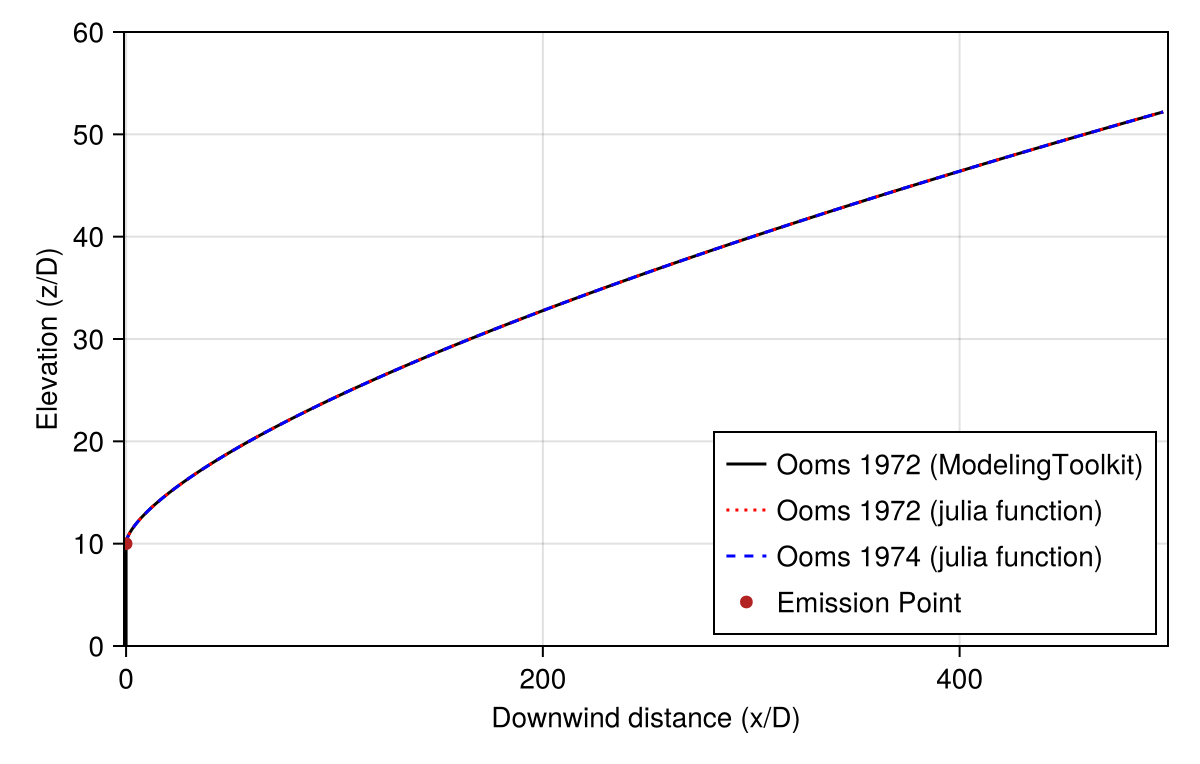

In [38]:
#| echo: false
#| label: fig-broken-out-models
#| fig-cap: "The plume height as a function of downwind distance, comparing the original ModelingToolkit results with the pure julia function implementations."
f3 = Figure(figurepadding=0)
ax3 = Axis(f3[1, 1],
    xlabel = "Downwind distance (x/D)",
    ylabel = "Elevation (z/D)",
    limits = ((-1,500),(0,60)),
    #aspect = DataAspect()
)
plot!(ax3, sol_ooms1972, idxs=(x,z), color=:black, label="Ooms 1972 (ModelingToolkit)")
plot!(ax3, ooms_1972_sol, idxs=(6,7), color=:red, linestyle=:dot, label="Ooms 1972 (julia function)")
plot!(ax3, ooms_1974_sol, idxs=(6,7), color=:blue, linestyle=:dash, label="Ooms 1974 (julia function)")
lines!(ax3, [0, 0], [0, h/D], color=:black, label=nothing)
scatter!(ax3, [0], [h/D], color=:firebrick, label="Emission Point")
axislegend(position=:rb)
rowsize!(f3.layout,1,Aspect(1, 30/51))
resize_to_layout!(f3)
f3
     

## Final Thoughts

The version of the Ooms plume dispersion model given here, in particular in the pure julia functions, is equivalent to what is in the DEGADIS 1.0 fortran code. Which might be a useful tool if you are looking to re-create some analysis done with DEGADIS 1.0 and don't want to spend your time compiling legacy fortran code. A decidedly niche activity.

Outside of that, I'm not sure how much use these legacy integral models get these days. My main interest is in having simpler models to play around with, where all the model equations are easy to grasp. Many modern tools, starting with DEGADIS 2.0 as well as PHAST, use similar integral plume model ideas but with much more complicated entrainment and thermodynamics models. It can be difficult to untagle what they are doing exactly and how different parameters impact the results.

## References
::: {#refs}
:::